# InStock — Clean Training & Evaluation Run
Single linear pipeline: install → seed → load/clean data → train all 5 models →
soft-voting ensemble → full evaluation suite → export figures + tables.

**Before running:** Runtime → Change runtime type → GPU (T4 is enough).
**Run order matters less here than before** — this notebook has no leftover/duplicate
training cells, so `Runtime → Run all` is safe and will not overwrite anything.

In [ ]:
# ==========================================================
# 1. INSTALL DEPENDENCIES
# ==========================================================
!pip install -q transformers datasets evaluate imbalanced-learn scikit-learn tensorflow torch matplotlib seaborn scipy tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# 2. IMPORTS, SEEDS, SETUP
# ==========================================================
import pandas as pd
import numpy as np
import os, gc, random, pickle
import joblib
import torch
import re
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                              matthews_corrcoef, log_loss, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE, RandomOverSampler
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           Trainer, TrainingArguments, set_seed)
from datasets import Dataset
from scipy.stats import chi2

# ---- Reproducibility: lock every RNG BEFORE anything trains ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)  # locks HuggingFace Trainer init/sampler/dropout RNGs

# ---- IEEE-safe plotting defaults (used later in evaluation section) ----
mpl.rcParams.update({
    'font.size': 8, 'font.family': 'serif', 'axes.titlesize': 9,
    'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'figure.dpi': 300, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'pdf.fonttype': 42,
})
IEEE_SINGLE_COL, IEEE_DOUBLE_COL = 3.45, 7.16

SAVE_DIR = "./production_models"
FIG_DIR = "./paper_figures"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"InStock pipeline booted. SEED={SEED}. Models -> {SAVE_DIR} | Figures -> {FIG_DIR}")

InStock pipeline booted. SEED=42. Models -> ./production_models | Figures -> ./paper_figures


In [ ]:
# ==========================================================
# 3. DATASET — upload if not already present in this session
# ==========================================================
import os
if not os.path.exists("scraped_dataset_NLP.csv"):
    from google.colab import files
    print("Upload scraped_dataset_NLP.csv:")
    uploaded = files.upload()
else:
    print("scraped_dataset_NLP.csv already present in this session.")

Upload scraped_dataset_NLP.csv:


Saving scraped_dataset_NLP.csv to scraped_dataset_NLP.csv


In [ ]:
# ==========================================================
# 4. DATA LOADING, CLEANING, SPLIT (80-20, as decided for simplicity)
# ==========================================================
df = pd.read_csv('scraped_dataset_NLP.csv')
df = df.dropna(subset=['Judul', 'Sentimen'])

X_raw = df['Judul'].astype(str)
y_text = df['Sentimen']

def clean_financial_headline(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # keep letters, numbers, spaces, and financial symbols incl. direction arrows
    text = re.sub(r'[^\w\s\$\%\+\-\.,\u2191\u2193]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning headlines: lowercasing, stripping noise, preserving $ % + - . , and direction arrows...")
X = X_raw.apply(clean_financial_headline)

label_mapping = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
target_names = ['Negatif', 'Netral', 'Positif']
y = y_text.map(label_mapping)
num_labels = 3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

pred_probs = {}
model_metrics = []

Cleaning headlines: lowercasing, stripping noise, preserving $ % + - . , and direction arrows...
Train: 2640 | Test: 660


In [ ]:
# ==========================================================
# 5. TRAIN & SAVE: SVM (with SMOTE)
# ==========================================================
print("[1/5] Training SVM (TF-IDF + SMOTE)...")
vectorizer = TfidfVectorizer(lowercase=True, max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

smote = SMOTE(random_state=SEED)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_vec, y_train)

svm_model = SVC(kernel='linear', probability=True, random_state=SEED)
svm_model.fit(X_train_resampled, y_train_resampled)

joblib.dump(svm_model, os.path.join(SAVE_DIR, "svm_model.pkl"))
joblib.dump(vectorizer, os.path.join(SAVE_DIR, "tfidf_vectorizer.pkl"))

pred_probs['SVM'] = svm_model.predict_proba(X_test_vec)
svm_pred = np.argmax(pred_probs['SVM'], axis=1)

model_metrics.append({
    'Model': 'SVM', 'Accuracy': accuracy_score(y_test, svm_pred),
    'F1-Score': f1_score(y_test, svm_pred, average='weighted'),
    'MCC': matthews_corrcoef(y_test, svm_pred), 'Log-Loss': log_loss(y_test, pred_probs['SVM'])
})
print("SVM done.")

[1/5] Training SVM (TF-IDF + SMOTE)...
SVM done.


In [ ]:
# ==========================================================
# 6. TRAIN & SAVE: BiLSTM
# ==========================================================
print("[2/5] Training BiLSTM...")
vocab_size, max_length = 5000, 50

bilstm_tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
bilstm_tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(bilstm_tokenizer.texts_to_sequences(X_train), maxlen=max_length, truncating='post')
X_test_seq = pad_sequences(bilstm_tokenizer.texts_to_sequences(X_test), maxlen=max_length, truncating='post')

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

bilstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_labels, activation='softmax')
])
bilstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
bilstm_model.fit(X_train_seq, y_train, epochs=5, batch_size=32, verbose=1, class_weight=class_weight_dict)

bilstm_model.save(os.path.join(SAVE_DIR, "bilstm_model.keras"))
with open(os.path.join(SAVE_DIR, "bilstm_tokenizer.pkl"), "wb") as f:
    pickle.dump(bilstm_tokenizer, f)

pred_probs['BiLSTM'] = bilstm_model.predict(X_test_seq)
bilstm_pred = np.argmax(pred_probs['BiLSTM'], axis=1)

model_metrics.append({
    'Model': 'BiLSTM', 'Accuracy': accuracy_score(y_test, bilstm_pred),
    'F1-Score': f1_score(y_test, bilstm_pred, average='weighted'),
    'MCC': matthews_corrcoef(y_test, bilstm_pred), 'Log-Loss': log_loss(y_test, pred_probs['BiLSTM'])
})
print("BiLSTM done.")

[2/5] Training BiLSTM...
Epoch 1/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.4587 - loss: 1.0392
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8383 - loss: 0.3925
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9655 - loss: 0.1103
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9917 - loss: 0.0381
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9966 - loss: 0.0112
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
BiLSTM done.


In [ ]:
# ==========================================================
# 7. TRAIN & SAVE: TRANSFORMERS (DistilBERT_Indo, RoBERTa_Indo, XLM_RoBERTa_Multi)
# ==========================================================
ros = RandomOverSampler(random_state=SEED)
X_train_ros, y_train_ros = ros.fit_resample(np.array(X_train).reshape(-1, 1), y_train)
X_train_ros = X_train_ros.flatten()

train_df = pd.DataFrame({'text': X_train_ros, 'label': y_train_ros})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

transformer_models = {
    "DistilBERT_Indo": "indobenchmark/indobert-base-p1",
    "RoBERTa_Indo": "w11wo/indonesian-roberta-base-sentiment-classifier",
    "XLM_RoBERTa_Multi": "xlm-roberta-base"
}

for i, (name, checkpoint) in enumerate(transformer_models.items(), start=3):
    print(f"[{i}/5] Training {name}...")

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=num_labels, ignore_mismatched_sizes=True
    )

    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_test = test_dataset.map(tokenize_function, batched=True)

    training_args = TrainingArguments(
        output_dir=f"./temp_{name}",
        eval_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        num_train_epochs=3,
        logging_steps=50,
        report_to="none",
        fp16=True,
        save_strategy="no",
        seed=SEED,
        data_seed=SEED,
    )

    trainer = Trainer(model=model, args=training_args, train_dataset=tokenized_train)
    trainer.train()

    model_save_path = os.path.join(SAVE_DIR, name)
    trainer.save_model(model_save_path)
    tokenizer.save_pretrained(model_save_path)
    print(f"{name} saved to {model_save_path}")

    raw_predictions = trainer.predict(tokenized_test)
    logits = raw_predictions.predictions
    probabilities = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
    pred_probs[name] = probabilities

    model_pred = np.argmax(probabilities, axis=1)
    model_metrics.append({
        'Model': name, 'Accuracy': accuracy_score(y_test, model_pred),
        'F1-Score': f1_score(y_test, model_pred, average='weighted'),
        'MCC': matthews_corrcoef(y_test, model_pred), 'Log-Loss': log_loss(y_test, probabilities)
    })

    del model, trainer, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("All transformers done.")

[3/5] Training DistilBERT_Indo...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

...

Map:   0%|          | 0/660 [00:00<?, ? examples/s]

Step,Training Loss
50,1.085633
100,1.052453
150,0.893697
200,0.725363
250,0.608909
300,0.493238
350,0.411157
400,0.337587
450,0.320038


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

XLM_RoBERTa_Multi saved to ./production_models/XLM_RoBERTa_Multi


All transformers done.


In [ ]:
# ==========================================================
# 8. SOFT-VOTING ENSEMBLE (equal-weight average — matches paper Eq. 1)
# ==========================================================
ensemble_probs = sum(pred_probs.values()) / len(pred_probs)
ensemble_pred = np.argmax(ensemble_probs, axis=1)

model_metrics.append({
    'Model': 'Ensemble (Soft-Voting)', 'Accuracy': accuracy_score(y_test, ensemble_pred),
    'F1-Score': f1_score(y_test, ensemble_pred, average='weighted'),
    'MCC': matthews_corrcoef(y_test, ensemble_pred), 'Log-Loss': log_loss(y_test, ensemble_probs)
})

comparison_df = pd.DataFrame(model_metrics)
print("\n=== ALL MODELS — COMPARISON ===")
print(comparison_df.to_string(index=False))

print("\n=== CLASSIFICATION REPORT: ENSEMBLE ===")
print(classification_report(y_test, ensemble_pred, target_names=target_names))


=== ALL MODELS — COMPARISON ===
                 Model  Accuracy  F1-Score      MCC  Log-Loss
                   SVM  0.940909  0.941201 0.911599  0.217078
                BiLSTM  0.906061  0.906454 0.859271  0.324990
       DistilBERT_Indo  0.959091  0.959035 0.938659  0.180220
          RoBERTa_Indo  0.886364  0.886143 0.829694  0.347075
     XLM_RoBERTa_Multi  0.875758  0.874321 0.815173  0.377369
Ensemble (Soft-Voting)  0.956061  0.955987 0.934171  0.175415

=== CLASSIFICATION REPORT: ENSEMBLE ===
              precision    recall  f1-score   support

     Negatif       0.97      0.97      0.97       220
      Netral       0.95      0.93      0.94       220
     Positif       0.95      0.97      0.96       220

    accuracy                           0.96       660
   macro avg       0.96      0.96      0.96       660
weighted avg       0.96      0.96      0.96       660



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


                 Model  Accuracy  Weighted F1  Macro F1   MCC  Log-Loss
                   SVM     0.941        0.941     0.941 0.912     0.217
                BiLSTM     0.906        0.906     0.906 0.859     0.325
       DistilBERT_Indo     0.959        0.959     0.959 0.939     0.180
          RoBERTa_Indo     0.886        0.886     0.886 0.830     0.347
     XLM_RoBERTa_Multi     0.876        0.874     0.874 0.815     0.377
Ensemble (Soft-Voting)     0.956        0.956     0.956 0.934     0.175


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


saved fig1_metric_comparison.pdf / .png


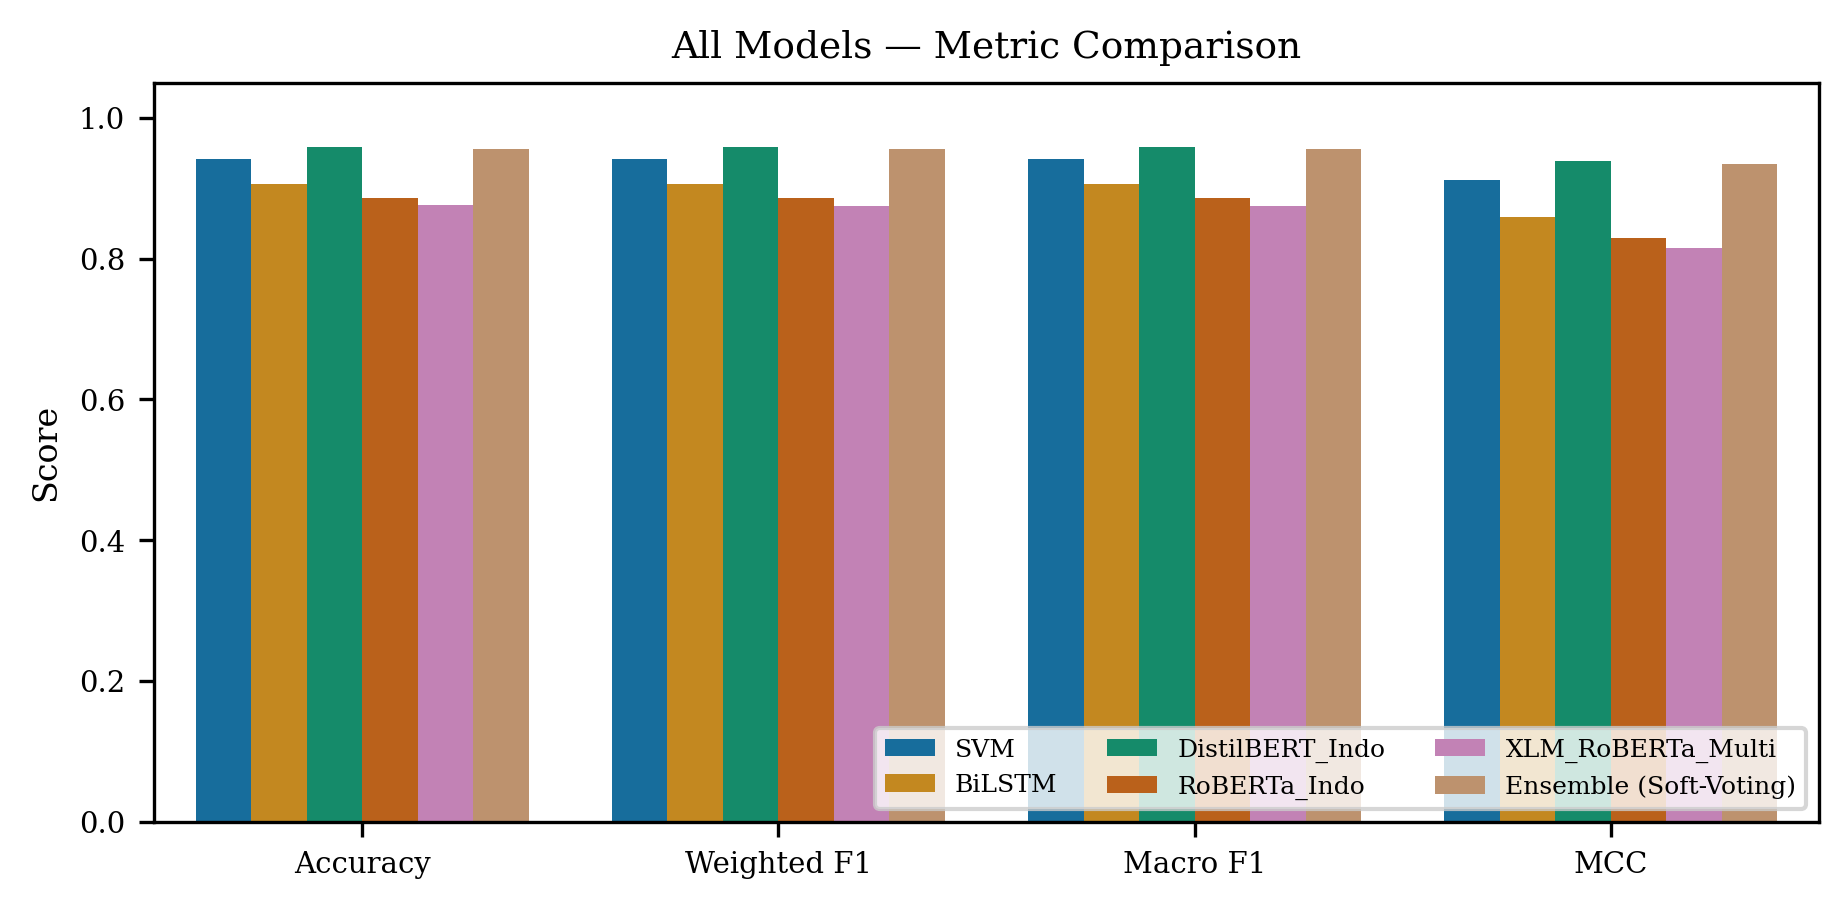

saved fig2_per_class_heatmap.pdf / .png


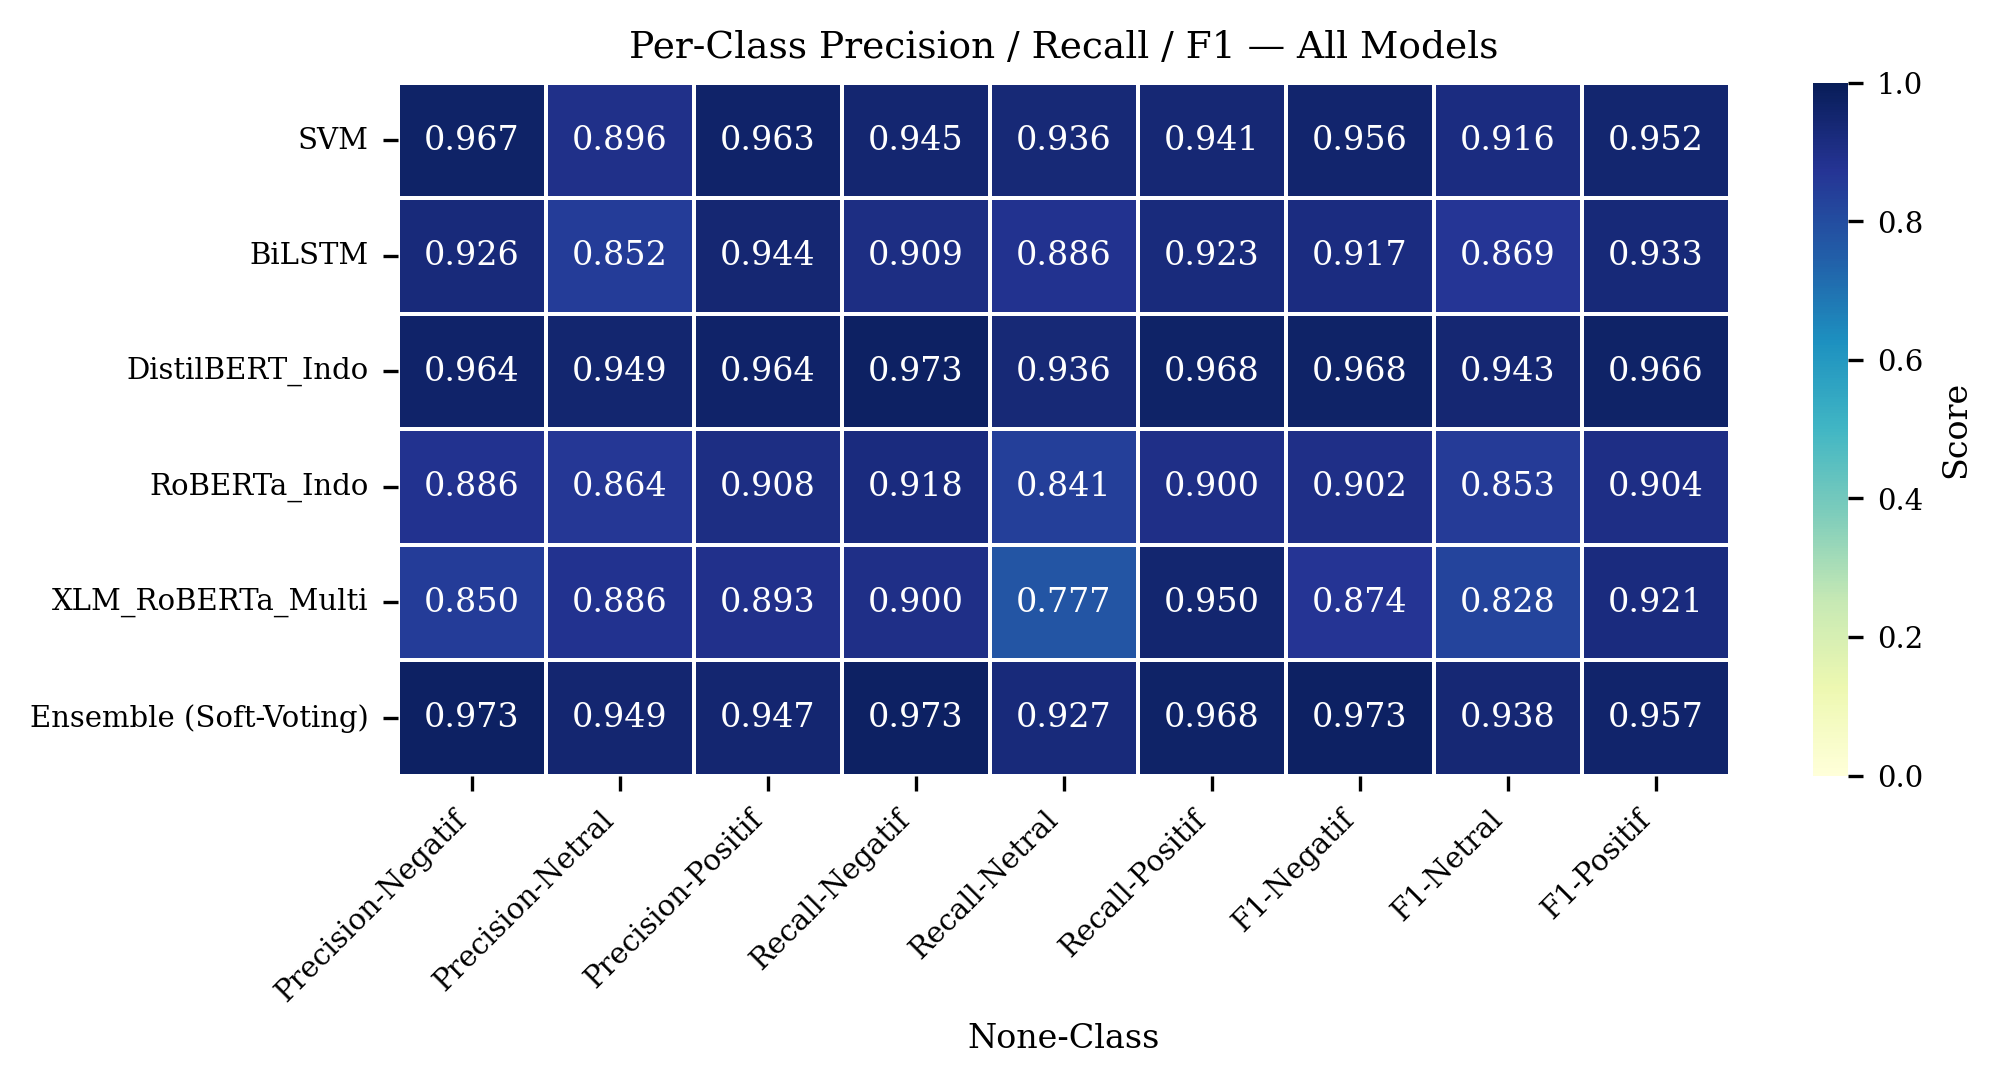

saved fig3_confusion_matrices.pdf / .png


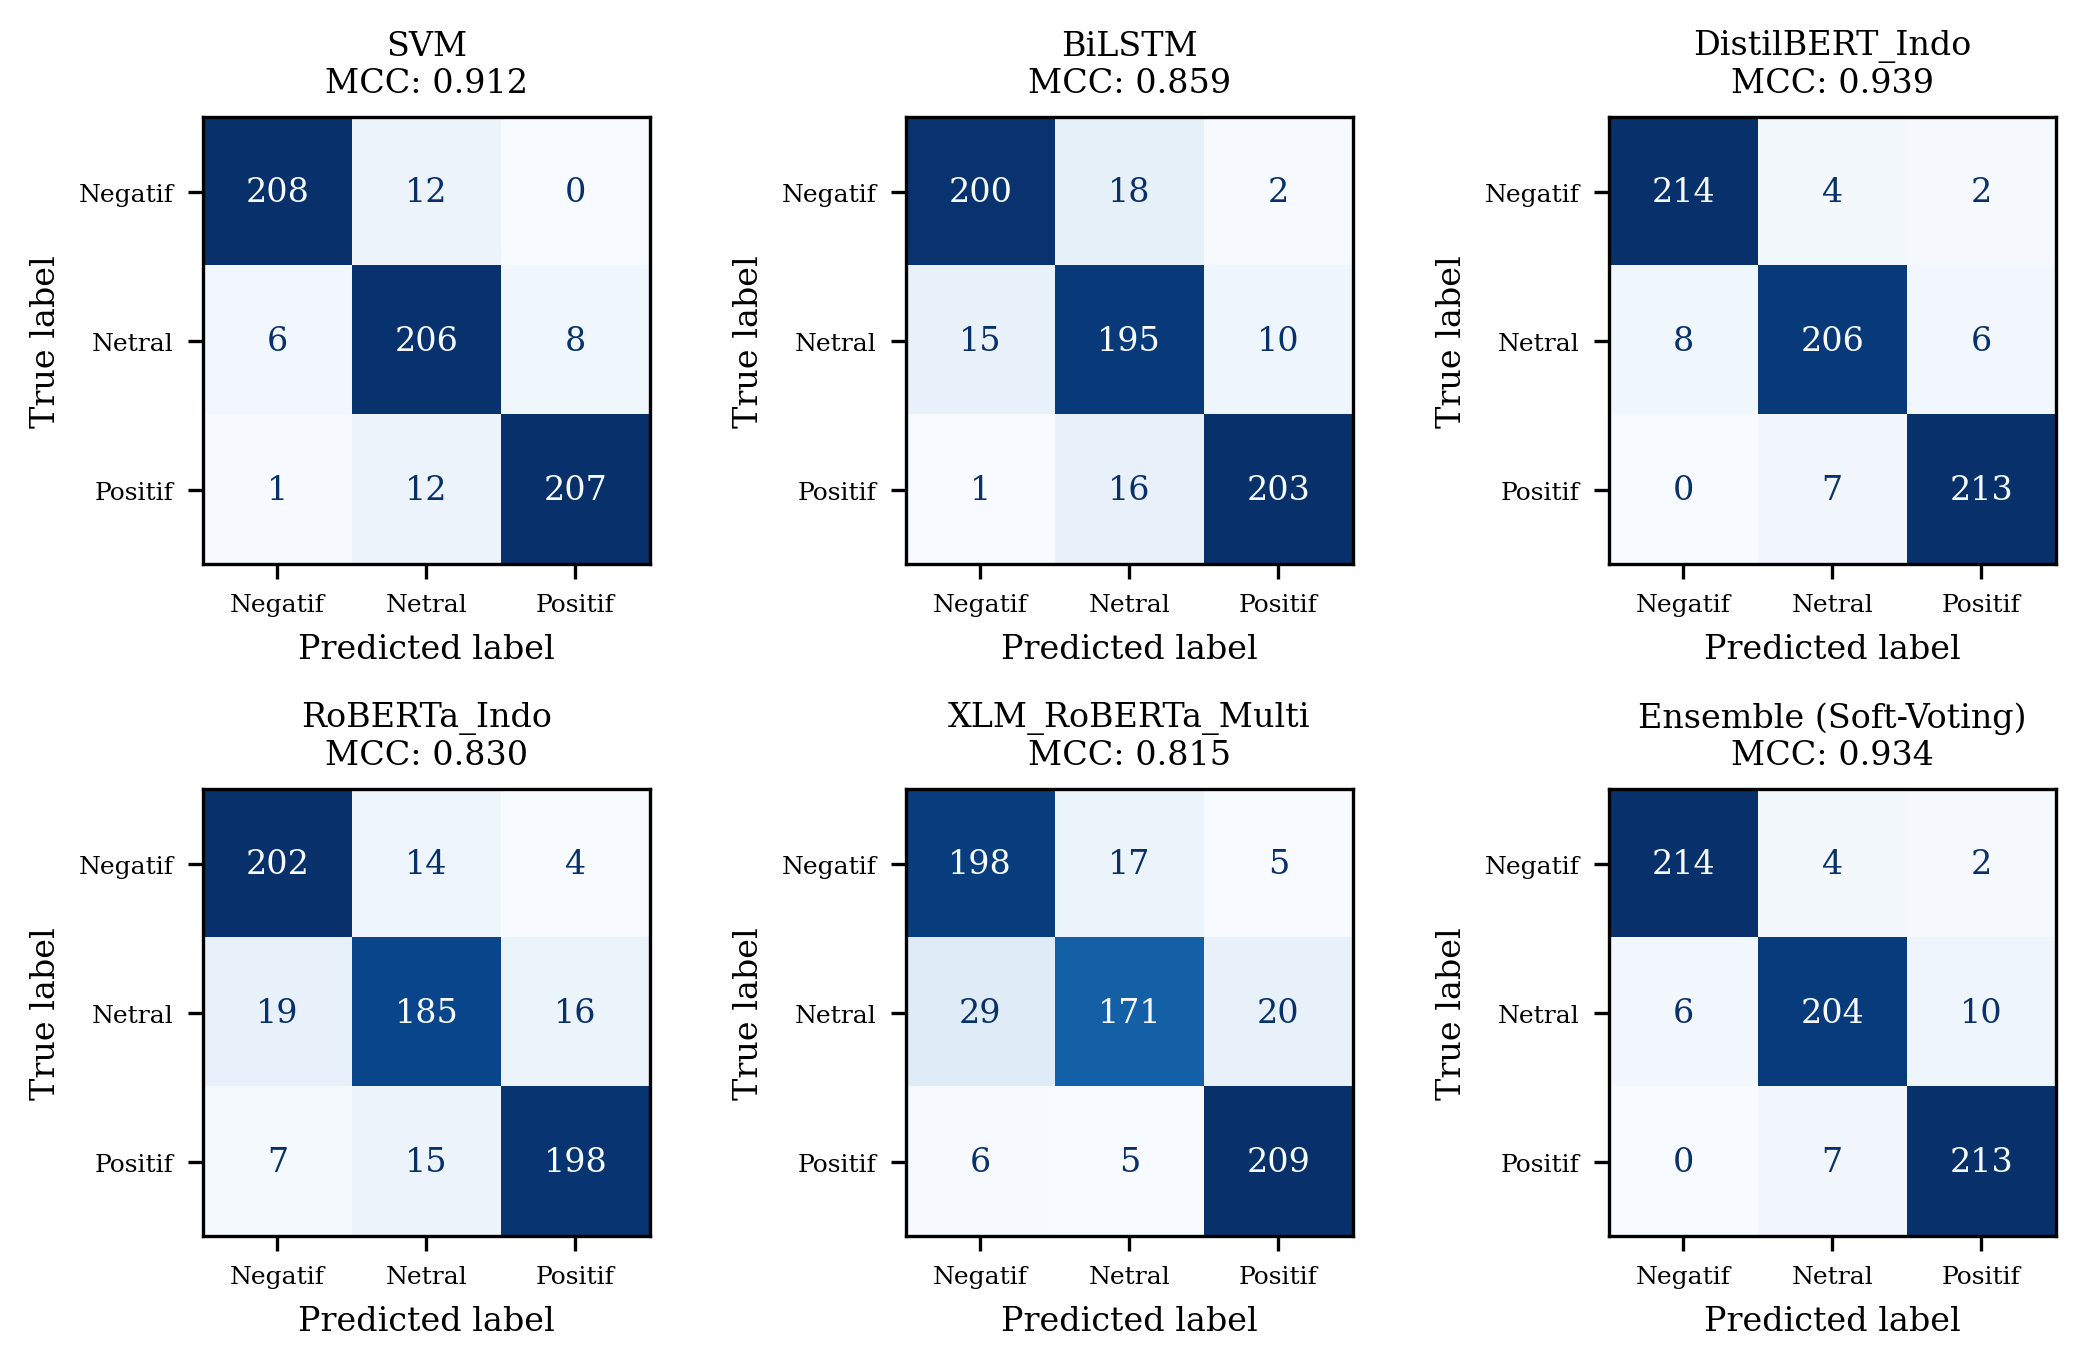

saved fig4_roc_curves.pdf / .png


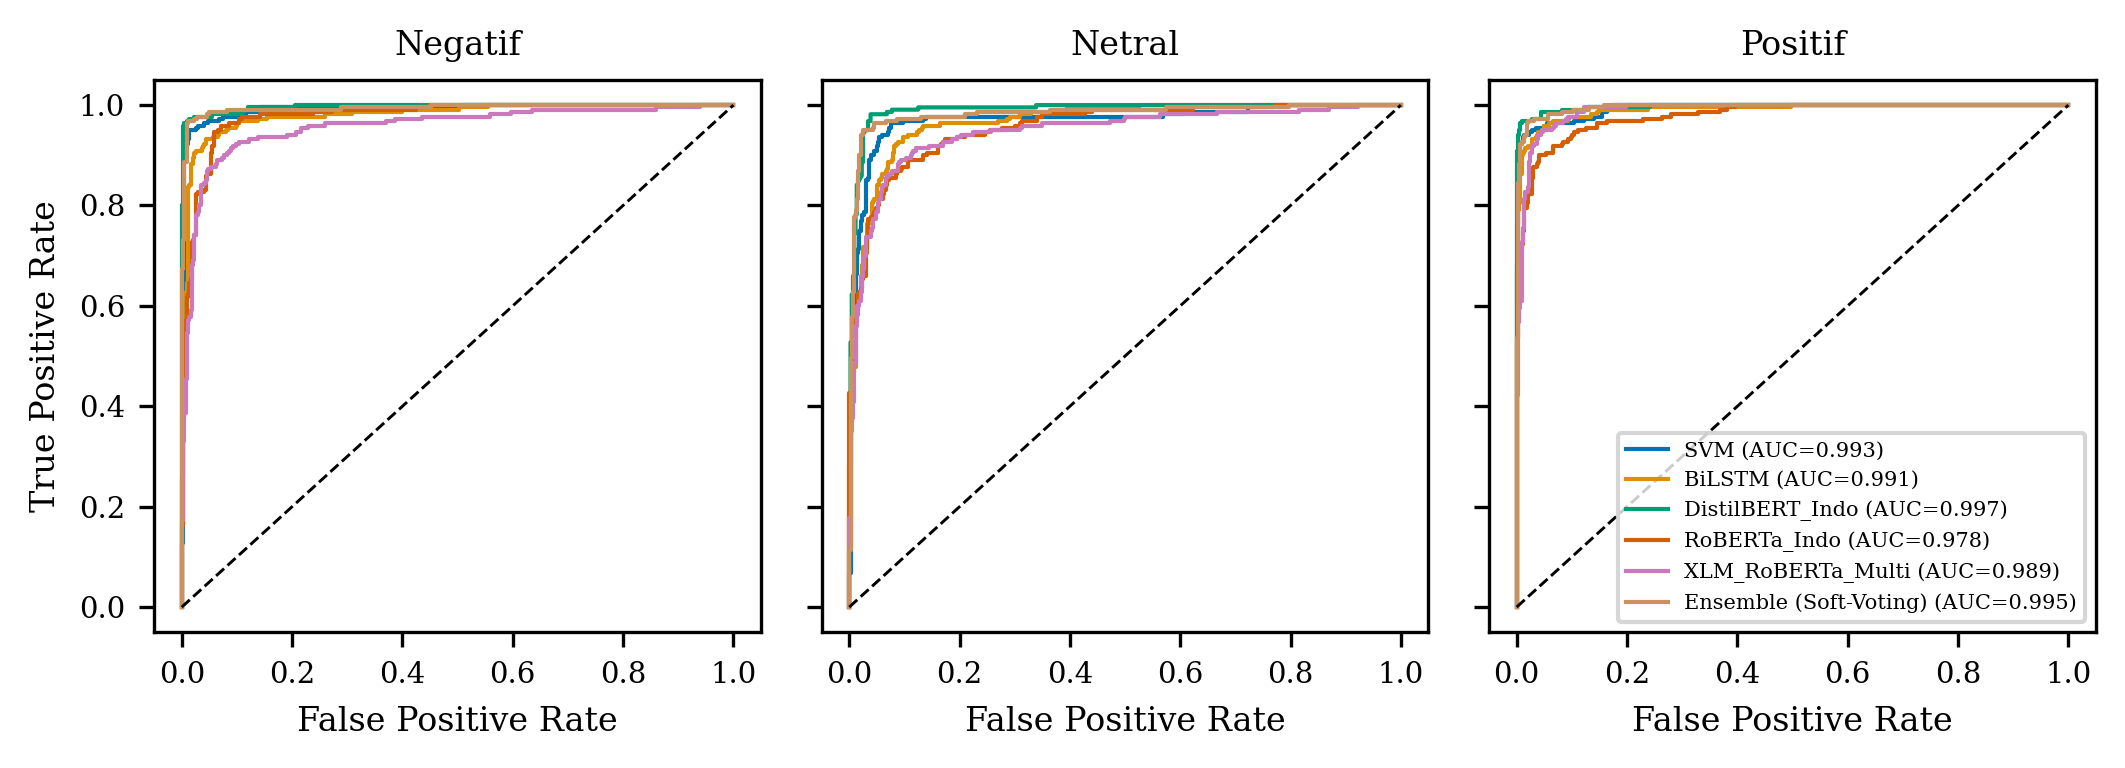

saved fig5_calibration.pdf / .png


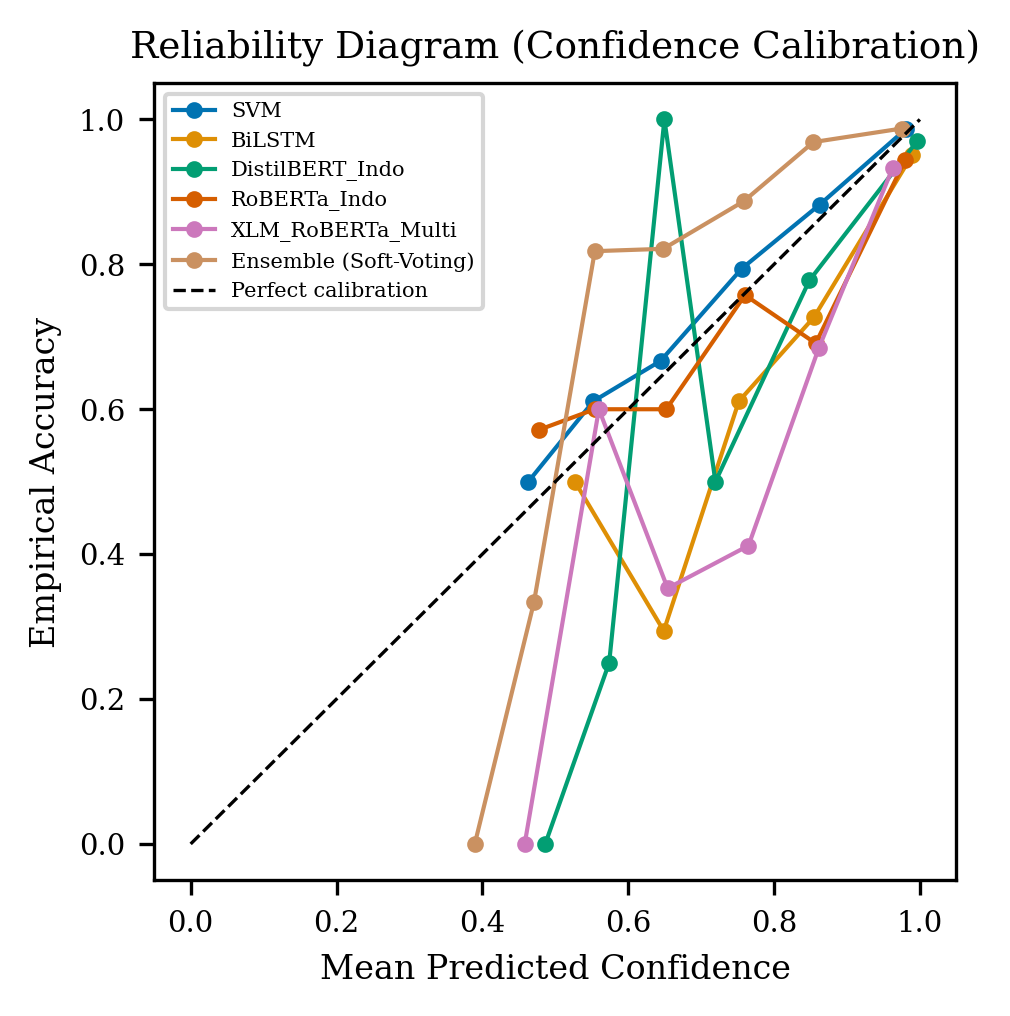


=== McNemar significance tests (alpha=0.05) ===
SVM vs Ensemble: b=8, c=18, chi2=3.115, p=0.0776 -> not significant
DistilBERT_Indo vs Ensemble: b=9, c=7, chi2=0.062, p=0.8026 -> not significant
SVM vs DistilBERT_Indo: b=9, c=21, chi2=4.033, p=0.0446 -> SIGNIFICANT (p<0.05)

All figures + tables saved to ./paper_figures/


In [ ]:
# ==========================================================
# 9. EXTENDED EVALUATION — IEEE-ready figures + tables
# (Fig 1: 4-metric bar | Fig 2: per-class heatmap | Fig 3: 6-model confusion grid
#  Fig 4: ROC curves | Fig 5: calibration diagram | McNemar significance tests)
# ==========================================================
MODEL_ORDER = ['SVM', 'BiLSTM', 'DistilBERT_Indo', 'RoBERTa_Indo',
               'XLM_RoBERTa_Multi', 'Ensemble (Soft-Voting)']

probs_dict = dict(pred_probs)
probs_dict['Ensemble (Soft-Voting)'] = ensemble_probs
preds_dict = {name: np.argmax(p, axis=1) for name, p in probs_dict.items()}
y_test_arr = np.array(y_test)

def save_fig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.pdf"))
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=300)
    print(f"saved {name}.pdf / .png")

# ---- Full metrics table ----
rows = []
for name in MODEL_ORDER:
    p, pred = probs_dict[name], preds_dict[name]
    rows.append({
        'Model': name, 'Accuracy': accuracy_score(y_test_arr, pred),
        'Weighted F1': f1_score(y_test_arr, pred, average='weighted'),
        'Macro F1': f1_score(y_test_arr, pred, average='macro'),
        'MCC': matthews_corrcoef(y_test_arr, pred),
        'Log-Loss': log_loss(y_test_arr, p),
    })
full_metrics_df = pd.DataFrame(rows)
full_metrics_df.to_csv(os.path.join(FIG_DIR, "metrics_table.csv"), index=False)
with open(os.path.join(FIG_DIR, "metrics_table.md"), "w") as f:
    f.write(full_metrics_df.round(3).to_markdown(index=False))
print(full_metrics_df.round(3).to_string(index=False))

# ---- Fig 1: grouped metric bar chart ----
plot_df = full_metrics_df.melt(id_vars='Model', value_vars=['Accuracy', 'Weighted F1', 'Macro F1', 'MCC'],
                                var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL, 3.2))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', ax=ax, palette='colorblind')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_xlabel('')
ax.legend(loc='lower right', ncol=3, frameon=True, fontsize=6)
ax.set_title('All Models — Metric Comparison')
save_fig(fig, "fig1_metric_comparison"); plt.show()

# ---- Fig 2: per-class heatmap ----
records = []
for name in MODEL_ORDER:
    report = classification_report(y_test_arr, preds_dict[name], target_names=target_names, output_dict=True)
    for cls in target_names:
        records.append({'Model': name, 'Class': cls, 'Precision': report[cls]['precision'],
                         'Recall': report[cls]['recall'], 'F1': report[cls]['f1-score']})
per_class_df = pd.DataFrame(records)
heat_df = per_class_df.pivot(index='Model', columns='Class', values=['Precision', 'Recall', 'F1']).reindex(MODEL_ORDER)
fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL, 3.0))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1,
            cbar_kws={'label': 'Score'}, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Per-Class Precision / Recall / F1 — All Models'); ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
save_fig(fig, "fig2_per_class_heatmap"); plt.show()

# ---- Fig 3: confusion matrices, all 6 models ----
fig, axes = plt.subplots(2, 3, figsize=(IEEE_DOUBLE_COL, 4.6))
for ax, name in zip(axes.flat, MODEL_ORDER):
    cm = confusion_matrix(y_test_arr, preds_dict[name])
    mcc = matthews_corrcoef(y_test_arr, preds_dict[name])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f"{name}\nMCC: {mcc:.3f}", fontsize=8); ax.grid(False); ax.tick_params(labelsize=6)
plt.tight_layout()
save_fig(fig, "fig3_confusion_matrices"); plt.show()

# ---- Fig 4: ROC curves (One-vs-Rest) ----
y_test_bin = label_binarize(y_test_arr, classes=[0, 1, 2])
fig, axes = plt.subplots(1, 3, figsize=(IEEE_DOUBLE_COL, 2.6), sharey=True)
colors = sns.color_palette('colorblind', n_colors=len(MODEL_ORDER))
for ci, cls_name in enumerate(target_names):
    for name, color in zip(MODEL_ORDER, colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, ci], probs_dict[name][:, ci])
        roc_auc = auc(fpr, tpr)
        axes[ci].plot(fpr, tpr, color=color, lw=1, label=f"{name} (AUC={roc_auc:.3f})")
    axes[ci].plot([0, 1], [0, 1], 'k--', lw=0.7); axes[ci].set_title(cls_name, fontsize=8)
    axes[ci].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right', fontsize=5, frameon=True)
plt.tight_layout()
save_fig(fig, "fig4_roc_curves"); plt.show()

# ---- Fig 5: reliability / calibration diagram ----
fig, ax = plt.subplots(figsize=(IEEE_SINGLE_COL, IEEE_SINGLE_COL))
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
for name, color in zip(MODEL_ORDER, colors):
    confidences = probs_dict[name].max(axis=1)
    correct = (preds_dict[name] == y_test_arr).astype(int)
    bin_acc, bin_conf = [], []
    for i in range(n_bins):
        mask = (confidences >= bin_edges[i]) & (confidences < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_acc.append(correct[mask].mean()); bin_conf.append(confidences[mask].mean())
    ax.plot(bin_conf, bin_acc, marker='o', ms=3, lw=1, color=color, label=name)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Confidence'); ax.set_ylabel('Empirical Accuracy')
ax.set_title('Reliability Diagram (Confidence Calibration)')
ax.legend(fontsize=5, loc='upper left')
save_fig(fig, "fig5_calibration"); plt.show()

# ---- McNemar significance tests ----
def mcnemar_test(y_true, pred_a, pred_b, name_a, name_b):
    correct_a, correct_b = (pred_a == y_true), (pred_b == y_true)
    b = np.sum(correct_a & ~correct_b); c = np.sum(~correct_a & correct_b)
    if b + c == 0:
        print(f"{name_a} vs {name_b}: no discordant pairs, test undefined"); return
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p = chi2.sf(stat, df=1)
    print(f"{name_a} vs {name_b}: b={b}, c={c}, chi2={stat:.3f}, p={p:.4f} "
          f"-> {'SIGNIFICANT (p<0.05)' if p < 0.05 else 'not significant'}")

print("\n=== McNemar significance tests (alpha=0.05) ===")
mcnemar_test(y_test_arr, preds_dict['SVM'], preds_dict['Ensemble (Soft-Voting)'], 'SVM', 'Ensemble')
mcnemar_test(y_test_arr, preds_dict['DistilBERT_Indo'], preds_dict['Ensemble (Soft-Voting)'], 'DistilBERT_Indo', 'Ensemble')
mcnemar_test(y_test_arr, preds_dict['SVM'], preds_dict['DistilBERT_Indo'], 'SVM', 'DistilBERT_Indo')

print(f"\nAll figures + tables saved to {FIG_DIR}/")

In [ ]:
# ==========================================================
# 10. PACKAGE EVERYTHING FOR DOWNLOAD
# ==========================================================
!zip -r production_models.zip ./production_models -x "*.git*" > /dev/null
!zip -r paper_figures.zip ./paper_figures > /dev/null
print("production_models.zip and paper_figures.zip are ready in the file browser.")

# Optional: copy straight to Drive instead of manual download
from google.colab import drive
drive.mount('/content/drive')
!cp production_models.zip paper_figures.zip /content/drive/MyDrive/

production_models.zip and paper_figures.zip are ready in the file browser.
Mounted at /content/drive
